<a href="https://colab.research.google.com/github/Mohit2593/leo-congestion-india/blob/main/leo_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LEO Congestion Analysis — India's Space Debris Footprint
**Author:** Mohit Agarwal  
**Data Source:** Space-Track.org (US Space Force) — Live orbital catalog  
**Date:** May 2026

## Problem Statement
As Skyroot Aerospace prepares India's first private orbital launch into Low Earth Orbit,
how congested is the target altitude band — and how responsible has India been
in the debris it has already left behind?

## Data
- 61,274 tracked LEO objects from Space-Track.org
- Filtered: MEAN_MOTION > 11.25, ECCENTRICITY < 0.25
- Processed with Apache Spark 4.0.2

## Key Findings Summary
1. **LEO is more junk than satellites** — 52% of tracked objects are debris
2. **India is 6th largest LEO presence** — 659 objects, ahead of Japan
3. **One event explains India's debris history** — The 2001 PSLV-C3 upper stage
   fragmentation alone created 366 of India's 510 total debris objects
4. **India's 2020s debris ratio is 0.19** — among the cleanest of any spacefaring
   nation, down from a peak of 28.46 in the 2000s
5. **Skyroot's target zone (300-500km) carries 6,140 debris objects** —
   114 of them left by India itself

## Conclusion
India's apparent debris crisis is largely one event — not a pattern of
irresponsibility. India's current decade shows dramatic improvement.
The real question is whether India's private sector will continue
this trajectory as commercial launches accelerate.

"We are the first generation that can pollute space — and possibly the last that can choose not to."

In [ ]:
import requests
import pandas as pd
from google.colab import userdata

In [ ]:


email = userdata.get("SPACETRACK_EMAIL")
password = userdata.get("SPACETRACK_PASSWORD")

In [ ]:
# Login to Space-Track
session = requests.Session()
login = session.post(
    "https://www.space-track.org/ajaxauth/login",
    data={"identity": email,
      "password": password}
)

print("Login status:", login.status_code)  # 200 means success

Login status: 200


In [ ]:
# Pull LEO data from Space-Track
# LEO definition: MEAN_MOTION > 11.25 revs/day = below ~2000km altitude
# ECCENTRICITY < 0.25 = roughly circular orbits only
# This gives us all actively tracked LEO objects updated in last 30 days
url = (
    "https://www.space-track.org/basicspacedata/query"
    "/class/gp"
    "/MEAN_MOTION/>11.25"
    "/ECCENTRICITY/<0.25"
    "/format/json"
)

response = session.get(url)
data = response.json()

# Convert to Pandas
df_pandas = pd.DataFrame(data)

print(f"Total LEO objects: {len(df_pandas)}")
print(f"Columns: {list(df_pandas.columns)}")

Total LEO objects: 61274
Columns: ['CCSDS_OMM_VERS', 'COMMENT', 'CREATION_DATE', 'ORIGINATOR', 'OBJECT_NAME', 'OBJECT_ID', 'CENTER_NAME', 'REF_FRAME', 'TIME_SYSTEM', 'MEAN_ELEMENT_THEORY', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID', 'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS', 'OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'LAUNCH_DATE', 'SITE', 'DECAY_DATE', 'FILE', 'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2']


In [ ]:
# Convert to Spark DataFrame
df = spark.createDataFrame(df_pandas)

# First look — what types of objects are up there?
print("=== OBJECT TYPES ===")
df.groupBy("OBJECT_TYPE").count().orderBy("count", ascending=False).show()

# Which countries have the most objects in LEO?
print("=== TOP COUNTRIES IN LEO ===")
df.groupBy("COUNTRY_CODE").count().orderBy("count", ascending=False).show(20)

# Find all Indian objects
print("=== INDIA IN LEO ===")
df.filter(df.COUNTRY_CODE == "IND").select(
    "OBJECT_NAME", "OBJECT_TYPE", "LAUNCH_DATE", "PERIAPSIS", "APOAPSIS"
).show(50, truncate=False)

=== OBJECT TYPES ===
+-----------+-----+
|OBJECT_TYPE|count|
+-----------+-----+
|     DEBRIS|31760|
|    PAYLOAD|22328|
|ROCKET BODY| 5049|
|    UNKNOWN| 1989|
|        TBA|  148|
+-----------+-----+

=== TOP COUNTRIES IN LEO ===
+------------+-----+
|COUNTRY_CODE|count|
+------------+-----+
|          US|23154|
|         CIS|13752|
|        NULL|10916|
|         PRC| 8312|
|          FR|  794|
|          UK|  731|
|         IND|  659|
|         JPN|  635|
|         TBD|  576|
|         ESA|  136|
|          IT|  113|
|         GER|  109|
|         ISS|   95|
|         ORB|   92|
|        CHBZ|   91|
|          CA|   87|
|         SPN|   82|
|        GLOB|   79|
|        ARGN|   68|
|        SKOR|   64|
+------------+-----+
only showing top 20 rows
=== INDIA IN LEO ===
+-------------------+-----------+-----------+---------+--------+
|OBJECT_NAME        |OBJECT_TYPE|LAUNCH_DATE|PERIAPSIS|APOAPSIS|
+-------------------+-----------+-----------+---------+--------+
|ARYABHATA          |PAY

In [ ]:
from pyspark.sql.functions import col, when, count, round as spark_round

# Cast altitude columns to float
df = df.withColumn("PERIAPSIS", col("PERIAPSIS").cast("float")) \
       .withColumn("APOAPSIS", col("APOAPSIS").cast("float")) \
       .withColumn("LAUNCH_DATE", col("LAUNCH_DATE").cast("date"))

# Bin objects into altitude bands — Skyroot targets 300-500km
df = df.withColumn("ALTITUDE_BAND",
    when(col("PERIAPSIS") < 300, "Very Low (<300km)")
    .when(col("PERIAPSIS") < 500, "Low (300-500km) ← Skyroot zone")
    .when(col("PERIAPSIS") < 800, "Medium (500-800km)")
    .when(col("PERIAPSIS") < 1200, "High (800-1200km)")
    .otherwise("Very High (>1200km)")
)

# How congested is each altitude band?
print("=== LEO CONGESTION BY ALTITUDE BAND ===")
df.groupBy("ALTITUDE_BAND", "OBJECT_TYPE") \
  .count() \
  .orderBy("ALTITUDE_BAND", "count", ascending=False) \
  .show(30, truncate=False)

# India specifically — which bands are Indian objects in?
print("=== INDIA'S ALTITUDE DISTRIBUTION ===")
df.filter(col("COUNTRY_CODE") == "IND") \
  .groupBy("ALTITUDE_BAND", "OBJECT_TYPE") \
  .count() \
  .orderBy("ALTITUDE_BAND", ascending=True) \
  .show(20, truncate=False)

=== LEO CONGESTION BY ALTITUDE BAND ===
+------------------------------+-----------+-----+
|ALTITUDE_BAND                 |OBJECT_TYPE|count|
+------------------------------+-----------+-----+
|Very Low (<300km)             |DEBRIS     |13937|
|Very Low (<300km)             |PAYLOAD    |6100 |
|Very Low (<300km)             |ROCKET BODY|4025 |
|Very Low (<300km)             |UNKNOWN    |463  |
|Very Low (<300km)             |TBA        |27   |
|Very High (>1200km)           |PAYLOAD    |1052 |
|Very High (>1200km)           |DEBRIS     |1051 |
|Very High (>1200km)           |UNKNOWN    |185  |
|Very High (>1200km)           |ROCKET BODY|115  |
|Very High (>1200km)           |TBA        |3    |
|Medium (500-800km)            |DEBRIS     |7190 |
|Medium (500-800km)            |PAYLOAD    |4497 |
|Medium (500-800km)            |UNKNOWN    |591  |
|Medium (500-800km)            |ROCKET BODY|413  |
|Medium (500-800km)            |TBA        |64   |
|Low (300-500km) ← Skyroot zone|PAYLOAD   

In [ ]:
from pyspark.sql.functions import year, col, when

# How has India's debris footprint grown over decades?
print("=== INDIA'S DEBRIS GROWTH BY DECADE ===")
df.filter(
    (col("COUNTRY_CODE") == "IND") &
    (col("OBJECT_TYPE") == "DEBRIS") &
    (col("LAUNCH_DATE").isNotNull())
) \
.withColumn("DECADE",
    (year(col("LAUNCH_DATE")) / 10).cast("int") * 10
) \
.groupBy("DECADE") \
.count() \
.orderBy("DECADE") \
.show()

# The ratio problem — debris vs payload by country (top 10)
print("=== DEBRIS RESPONSIBILITY: WHO'S MAKING THE MESS? ===")
from pyspark.sql.functions import sum as spark_sum, round as spark_round

df.groupBy("COUNTRY_CODE") \
  .agg(
    spark_sum(when(col("OBJECT_TYPE") == "DEBRIS", 1).otherwise(0)).alias("debris"),
    spark_sum(when(col("OBJECT_TYPE") == "PAYLOAD", 1).otherwise(0)).alias("payloads")
  ) \
  .withColumn("debris_per_payload",
    spark_round(col("debris") / (col("payloads") + 1), 2)
  ) \
  .filter(col("payloads") > 20) \
  .orderBy("debris_per_payload", ascending=False) \
  .show(15)

=== INDIA'S DEBRIS GROWTH BY DECADE ===
+------+-----+
|DECADE|count|
+------+-----+
|  1980|    4|
|  1990|    3|
|  2000|  370|
|  2010|  127|
|  2020|    6|
+------+-----+

=== DEBRIS RESPONSIBILITY: WHO'S MAKING THE MESS? ===
+------------+------+--------+------------------+
|COUNTRY_CODE|debris|payloads|debris_per_payload|
+------------+------+--------+------------------+
|         IND|   510|      88|              5.73|
|         PRC|  6199|    1162|              5.33|
|         CIS| 10303|    1937|              5.32|
|          FR|   586|     127|              4.58|
|        NULL|  6169|    1719|              3.59|
|         ESA|    71|      46|              1.51|
|         JPN|   317|     217|              1.45|
|         ORB|    34|      58|              0.58|
|          US|  7366|   14975|              0.49|
|          CA|     5|      82|              0.06|
|        ISRA|     1|      26|              0.04|
|        GLOB|     2|      76|              0.03|
|         TWN|     1

In [ ]:
from pyspark.sql.functions import year, col, when, sum as spark_sum, round as spark_round

# Only look at post-2000 launches — modern era with debris guidelines
print("=== DEBRIS RESPONSIBILITY — MODERN ERA (2000s ONWARDS) ===")
df.filter(year(col("LAUNCH_DATE")) >= 2000) \
  .groupBy("COUNTRY_CODE") \
  .agg(
    spark_sum(when(col("OBJECT_TYPE") == "DEBRIS", 1).otherwise(0)).alias("debris"),
    spark_sum(when(col("OBJECT_TYPE") == "PAYLOAD", 1).otherwise(0)).alias("payloads")
  ) \
  .withColumn("debris_per_payload",
    spark_round(col("debris") / (col("payloads") + 1), 2)
  ) \
  .filter(col("payloads") > 20) \
  .orderBy("debris_per_payload", ascending=False) \
  .show(15)

# And India's own trend — are we getting better?
print("=== IS INDIA IMPROVING? DEBRIS RATIO BY DECADE ===")
df.filter(
    (col("COUNTRY_CODE") == "IND") &
    (col("LAUNCH_DATE").isNotNull())
  ) \
  .withColumn("DECADE",
    (year(col("LAUNCH_DATE")) / 10).cast("int") * 10
  ) \
  .groupBy("DECADE") \
  .agg(
    spark_sum(when(col("OBJECT_TYPE") == "DEBRIS", 1).otherwise(0)).alias("debris"),
    spark_sum(when(col("OBJECT_TYPE") == "PAYLOAD", 1).otherwise(0)).alias("payloads")
  ) \
  .withColumn("debris_per_payload",
    spark_round(col("debris") / (col("payloads") + 1), 2)
  ) \
  .orderBy("DECADE") \
  .show()

=== DEBRIS RESPONSIBILITY — MODERN ERA (2000s ONWARDS) ===
+------------+------+--------+------------------+
|COUNTRY_CODE|debris|payloads|debris_per_payload|
+------------+------+--------+------------------+
|         IND|   503|      74|              6.71|
|         CIS|  1473|     480|              3.06|
|         PRC|  2177|    1142|               1.9|
|         JPN|   270|     151|              1.78|
|          FR|    58|      99|              0.58|
|         ESA|    21|      41|               0.5|
|          US|  1413|   14204|               0.1|
|        ISRA|     1|      22|              0.04|
|         TWN|     1|      35|              0.03|
|        ARGN|     1|      64|              0.02|
|         POL|     0|      22|               0.0|
|         SPN|     0|      77|               0.0|
|         AUS|     0|      44|               0.0|
|          CA|     0|      69|               0.0|
|         ORB|     0|      23|               0.0|
+------------+------+--------+-----------

In [ ]:
# What specific launches caused the 2000s debris explosion?
print("=== WHAT CAUSED INDIA'S 2000s DEBRIS SPIKE? ===")
df.filter(
    (col("COUNTRY_CODE") == "IND") &
    (col("OBJECT_TYPE") == "DEBRIS") &
    (year(col("LAUNCH_DATE")).between(2000, 2009))
  ) \
  .groupBy("LAUNCH_DATE", "OBJECT_NAME") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(20, truncate=False)

=== WHAT CAUSED INDIA'S 2000s DEBRIS SPIKE? ===
+-----------+-----------+-----+
|LAUNCH_DATE|OBJECT_NAME|count|
+-----------+-----------+-----+
|2001-10-22 |PSLV DEB   |366  |
|2005-05-05 |PSLV DEB   |3    |
|2008-04-28 |PSLV DEB   |1    |
+-----------+-----------+-----+



## The simple version:
Space debris travels at 28,000 km/hour. That's 8 kilometers every second. At that speed, a paint fleck hits like a bullet. A marble hits like a hand grenade. A coffee-cup-sized fragment can destroy an entire satellite worth hundreds of millions of dollars.
And unlike Earth — there's no friction to slow things down. Debris stays up there for decades to centuries depending on altitude.

## The cascade problem — this is the scary part:
It's called Kessler Syndrome, proposed by NASA scientist Donald Kessler in 1978.
The logic is simple and terrifying:

Debris hits a satellite → creates more debris
More debris hits more satellites → creates even more debris
Eventually the density gets so high that any new satellite launched gets destroyed almost immediately
At that point — no GPS, no weather satellites, no internet satellites, no ISS, no future space exploration
Earth becomes permanently trapped under a shell of its own junk

We are not there yet. But some scientists believe certain orbital bands are already approaching the tipping point.

## What it means for India specifically:
India wants a $44 billion space economy by 2033. That means hundreds of satellites for:

 - Agricultural monitoring for farmers
 - Disaster early warning for floods and cyclones
 - Defence surveillance
 - Rural internet connectivity
 - Weather forecasting

Every piece of debris in the target orbital bands is a threat to every one of those satellites. India cannot build its space economy in a junkyard it helped create.

In [ ]:
# Keep only relevant columns for Power BI dashboard
cols_to_keep = [
    'OBJECT_NAME', 'OBJECT_TYPE', 'COUNTRY_CODE',
    'LAUNCH_DATE', 'DECAY_DATE', 'PERIAPSIS',
    'APOAPSIS', 'INCLINATION', 'RCS_SIZE', 'SITE'
]

df_powerbi = df_pandas[cols_to_keep]
df_powerbi.to_csv("leo_data_powerbi.csv", index=False)

from google.colab import files
files.download("leo_data_powerbi.csv")

print(f"Rows: {len(df_powerbi)}")
print(f"Columns: {len(df_powerbi.columns)}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Rows: 61274
Columns: 10


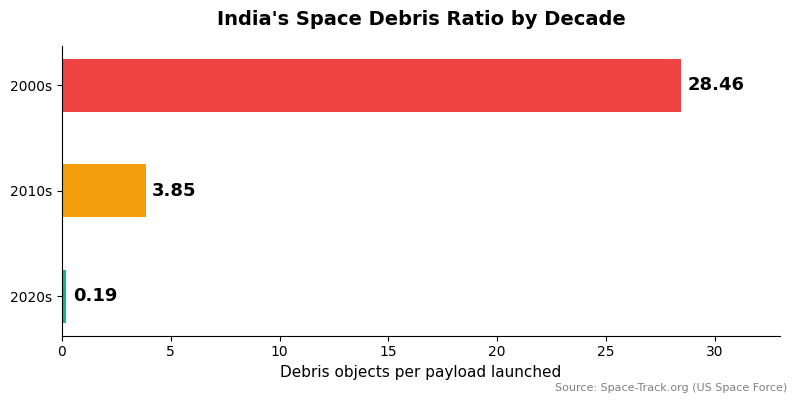

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import matplotlib.pyplot as plt

decades = ['2000s', '2010s', '2020s']
ratios = [28.46, 3.85, 0.19]
colors = ['#ef4444', '#f59e0b', '#10b981']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(decades, ratios, color=colors, height=0.5)

# Add value labels
for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{ratio}', va='center', fontsize=13, fontweight='bold')

ax.set_xlabel('Debris objects per payload launched', fontsize=11)
ax.set_title("India's Space Debris Ratio by Decade",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 33)
ax.invert_yaxis()

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.figtext(0.99, 0.01, 'Source: Space-Track.org (US Space Force)',
            ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('india_debris_trend.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('india_debris_trend.png')

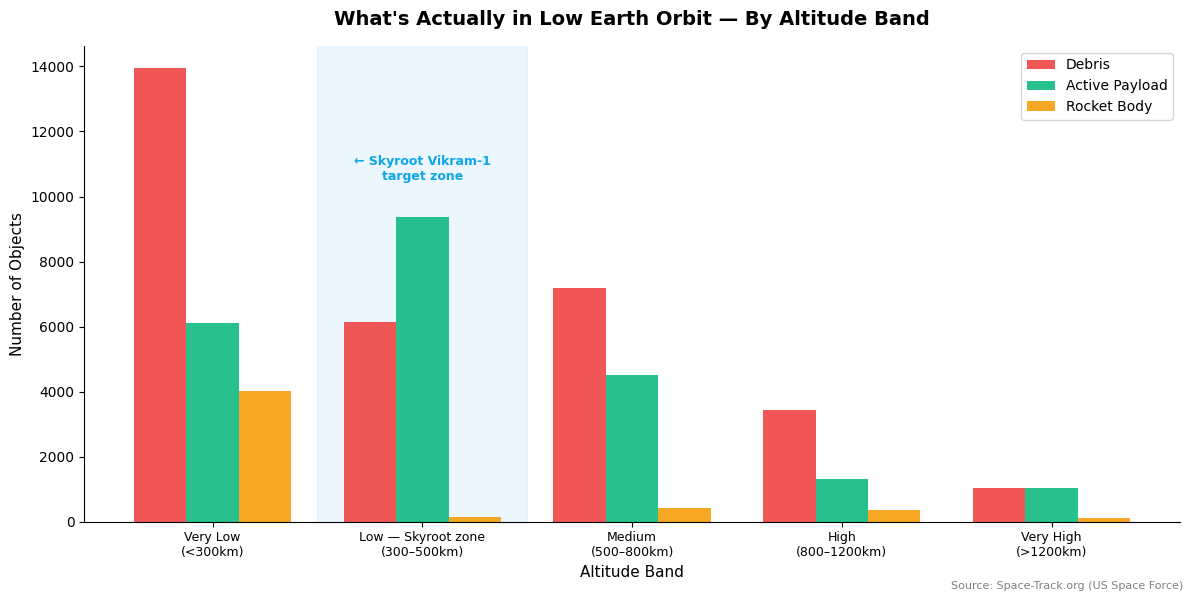

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Create altitude bands with counts from your analysis
bands = [
    'Very Low\n(<300km)',
    'Low — Skyroot zone\n(300–500km)',
    'Medium\n(500–800km)',
    'High\n(800–1200km)',
    'Very High\n(>1200km)'
]

debris =  [13937, 6140, 7190, 3442, 1051]
payloads = [6100, 9379, 4497, 1300, 1052]
rocket_bodies = [4025, 143, 413, 353, 115]

x = np.arange(len(bands))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, debris, width, label='Debris', color='#ef4444', alpha=0.9)
bars2 = ax.bar(x, payloads, width, label='Active Payload', color='#10b981', alpha=0.9)
bars3 = ax.bar(x + width, rocket_bodies, width, label='Rocket Body', color='#f59e0b', alpha=0.9)

# Highlight Skyroot zone
ax.axvspan(0.5, 1.5, alpha=0.08, color='#0ea5e9', zorder=0)
ax.text(1, 10500, '← Skyroot Vikram-1\ntarget zone',
        ha='center', fontsize=9, color='#0ea5e9', fontweight='bold')

ax.set_xlabel('Altitude Band', fontsize=11)
ax.set_ylabel('Number of Objects', fontsize=11)
ax.set_title("What's Actually in Low Earth Orbit — By Altitude Band",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=9)
ax.legend(fontsize=10)

# Clean look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.figtext(0.99, 0.01, 'Source: Space-Track.org (US Space Force)',
            ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('leo_altitude_congestion.png', dpi=150, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('leo_altitude_congestion.png')